In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [4]:
# Choose the used-cars CSV file from your computer
from google.colab import files

uploaded = files.upload()
csv_file = next(iter(uploaded))
df = pd.read_csv(csv_file)
print('Columns in dataset:', df.columns.tolist())


Saving diabetes_prediction_dataset.csv.zip to diabetes_prediction_dataset.csv (2).zip
Columns in dataset: ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']


In [5]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [6]:
df.tail()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0
99999,Female,57.0,0,0,current,22.43,6.6,90,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [8]:
df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


In [9]:
df.duplicated().sum()

np.int64(3854)

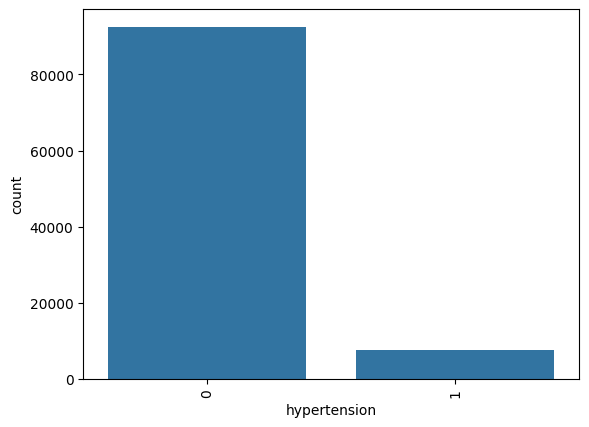

In [10]:
# Univariate Analysis
sns.countplot(x='hypertension', data=df)
plt.xticks(rotation=90)
plt.show()

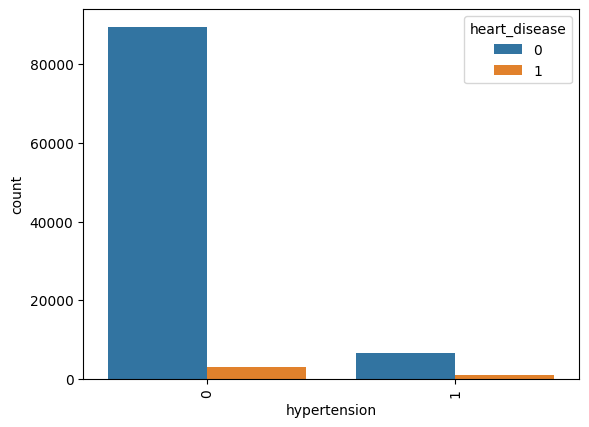

In [11]:
# Bivariate Analysis
sns.countplot(x='hypertension', hue='heart_disease', data=df)
plt.xticks(rotation=90)
plt.show()

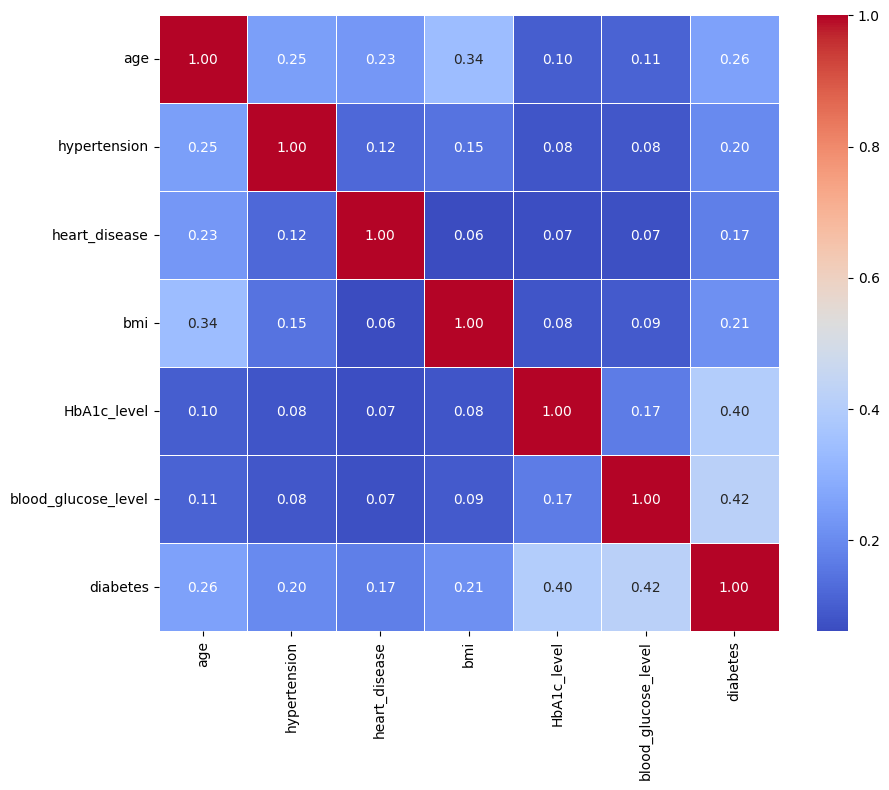

In [12]:
corr = df.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap = "coolwarm",fmt= ".2f",linewidth = 0.5)
plt.show()

In [14]:
df["gender"] = df["gender"].fillna(df["gender"].mode()[0])

In [15]:
df["age"] = df["age"].fillna(df["age"].mode()[0])

In [ ]:
Inputs: Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, and Age

In [16]:
df["hypertension"] = df["hypertension"].fillna(df["hypertension"].mode()[0])

In [17]:
df["heart_disease"] = df["heart_disease"].fillna(df["heart_disease"].mode()[0])

In [18]:
df["smoking_history"] = df["smoking_history"].fillna(df["smoking_history"].mode()[0])

In [19]:
df["bmi"] = df["bmi"].fillna(df["bmi"].mode()[0])

In [20]:
df["HbA1c_level"] = df["HbA1c_level"].fillna(df["HbA1c_level"].mode()[0])

In [21]:
df["blood_glucose_level"] = df["blood_glucose_level"].fillna(df["blood_glucose_level"].mode()[0])

In [22]:
df["diabetes"] = df["diabetes"].fillna(df["diabetes"].mode()[0])

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [24]:
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

for column in numerical_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_limit) |
        (df[column] > upper_limit)
    ]

    print(column, ":", len(outliers))

age : 0
hypertension : 7485
heart_disease : 3942
bmi : 7086
HbA1c_level : 1315
blood_glucose_level : 2038
diabetes : 8500


In [25]:
numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns.drop("diabetes")

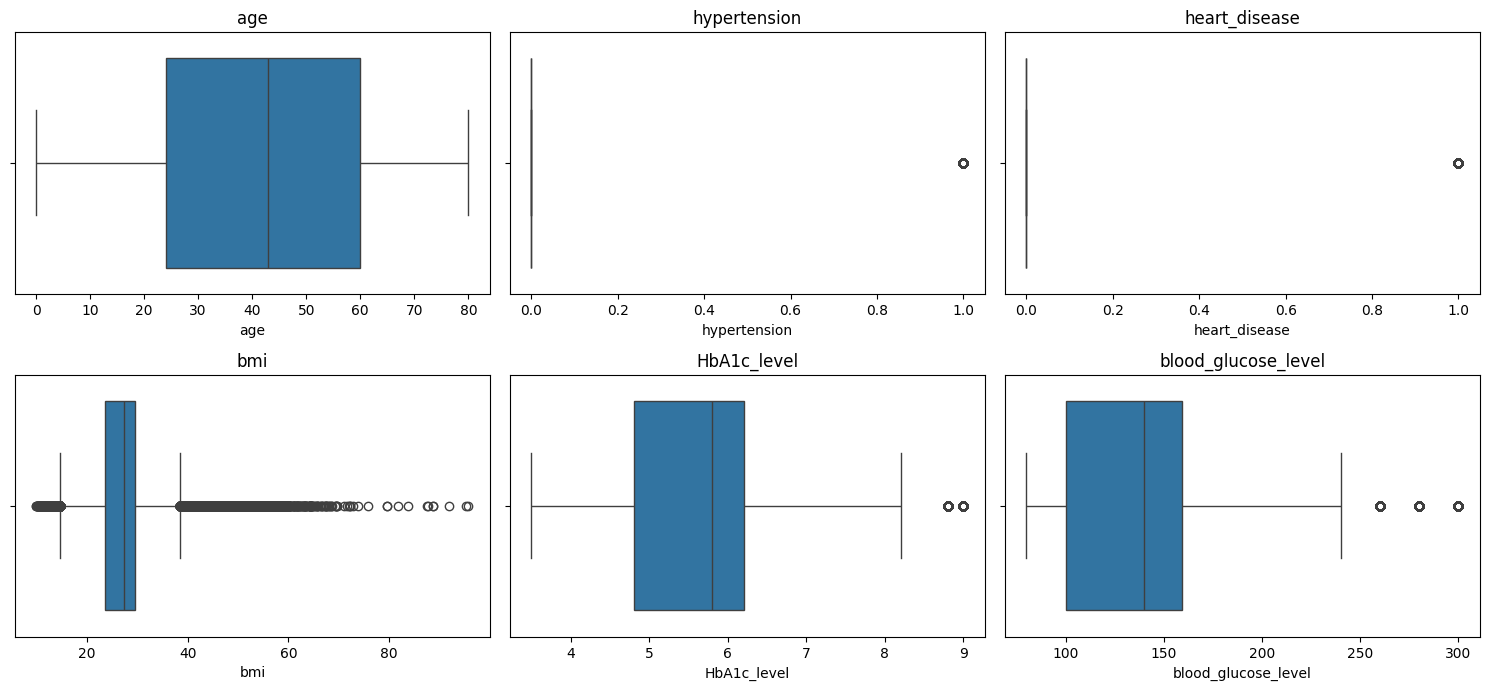

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))

for position, column in enumerate(numerical_columns, start=1):
    plt.subplot(3, 3, position)
    sns.boxplot(x=df[column])
    plt.title(column)

plt.tight_layout()
plt.show()

In [27]:
df_clean = df.copy()

for column in numerical_columns:
    Q1 = df_clean[column].quantile(0.25)
    Q3 = df_clean[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df_clean[column] = df_clean[column].clip(
        lower=lower_limit,
        upper=upper_limit
    )

In [28]:
for column in numerical_columns:
    Q1 = df_clean[column].quantile(0.25)
    Q3 = df_clean[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outlier_count = (
        (df_clean[column] < lower_limit) |
        (df_clean[column] > upper_limit)
    ).sum()

    print(column, ":", outlier_count)

age : 0
hypertension : 0
heart_disease : 0
bmi : 0
HbA1c_level : 0
blood_glucose_level : 0


In [29]:
X = df_clean.drop('diabetes', axis=1)

Y = df_clean['diabetes']

In [30]:
print(X.shape)
print(Y.shape)

(100000, 8)
(100000,)


In [31]:
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, classification_report

In [32]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Y_train shape: {Y_train.shape}")
print(f"Y_test shape: {Y_test.shape}")

X_train shape: (80000, 8)
X_test shape: (20000, 8)
Y_train shape: (80000,)
Y_test shape: (20000,)


In [34]:
# Encode categorical columns to numeric using One-Hot Encoding
X_encoded = pd.get_dummies(X, columns=['gender', 'smoking_history'], drop_first=True)


In [35]:
# Re-split the dataset with encoded features
X_train, X_test, Y_train, Y_test = train_test_split(X_encoded, Y, test_size=0.2, random_state=42)

In [36]:
# Initialize and fit the model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, Y_train)

LogisticRegression(max_iter=1000)

In [39]:
Y_pred = model.predict(X_test)

print(f"Accuracy Score: {accuracy_score(Y_test, Y_pred)}")

print("Classification Report:\n", classification_report(Y_test, Y_pred))

Accuracy Score: 0.95835
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.98     18292
           1       0.86      0.61      0.71      1708

    accuracy                           0.96     20000
   macro avg       0.91      0.80      0.85     20000
weighted avg       0.96      0.96      0.95     20000



In [40]:
Y_pred = model.predict(X_test)

In [41]:
accuracy_score(Y_test, Y_pred)

0.95835

In [42]:
classification_report(Y_test, Y_pred)

'              precision    recall  f1-score   support\n\n           0       0.96      0.99      0.98     18292\n           1       0.86      0.61      0.71      1708\n\n    accuracy                           0.96     20000\n   macro avg       0.91      0.80      0.85     20000\nweighted avg       0.96      0.96      0.95     20000\n'

In [38]:
!pip install imbalanced-learn

In [44]:
from imblearn.over_sampling import SMOTE

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


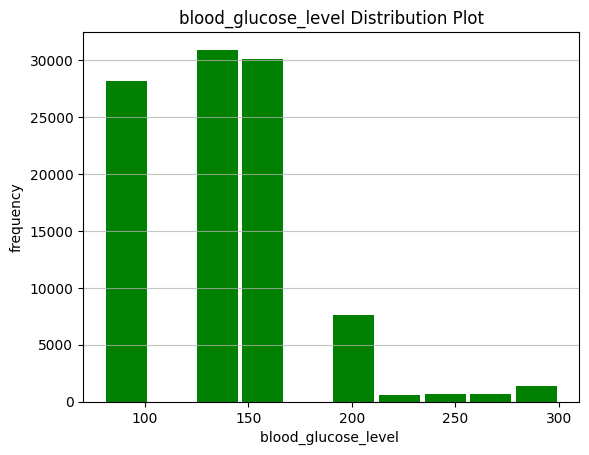

In [48]:
df.blood_glucose_level.plot(color="green", kind="hist", rwidth=0.9)
plt.xlabel("blood_glucose_level ")
plt.ylabel("frequency")
plt.title("blood_glucose_level Distribution Plot")
plt.grid(axis='y', alpha=0.75)
plt.show()

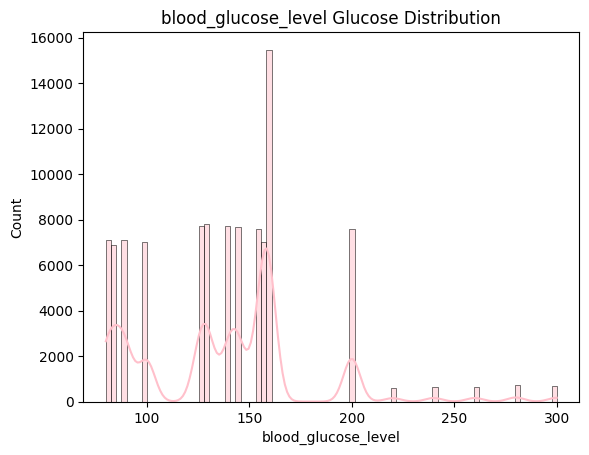

In [49]:
# Use 'df' instead of 'data' and 'sns.histplot' for continuous numeric variables like Glucose
sns.histplot(data=df, x="blood_glucose_level", color="pink", kde=True)
plt.title("blood_glucose_level Glucose Distribution")
plt.show()

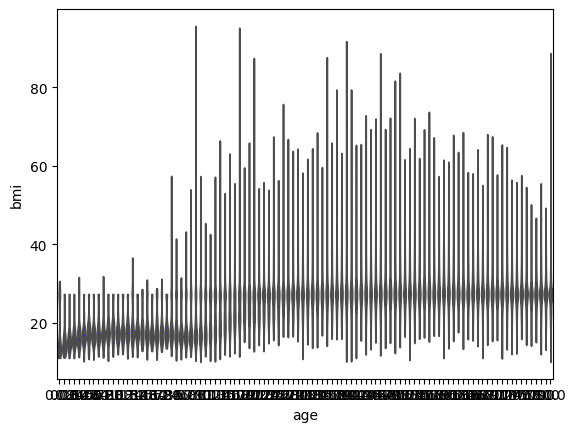

In [51]:
sns.violinplot(data=df, x="age", y="bmi", color="blue", split=False, cut=0, bw_method=0.3, inner="stick")
plt.show()

In [54]:
df.hypertension.value_counts()

,count
hypertension,
0,92515
1,7485


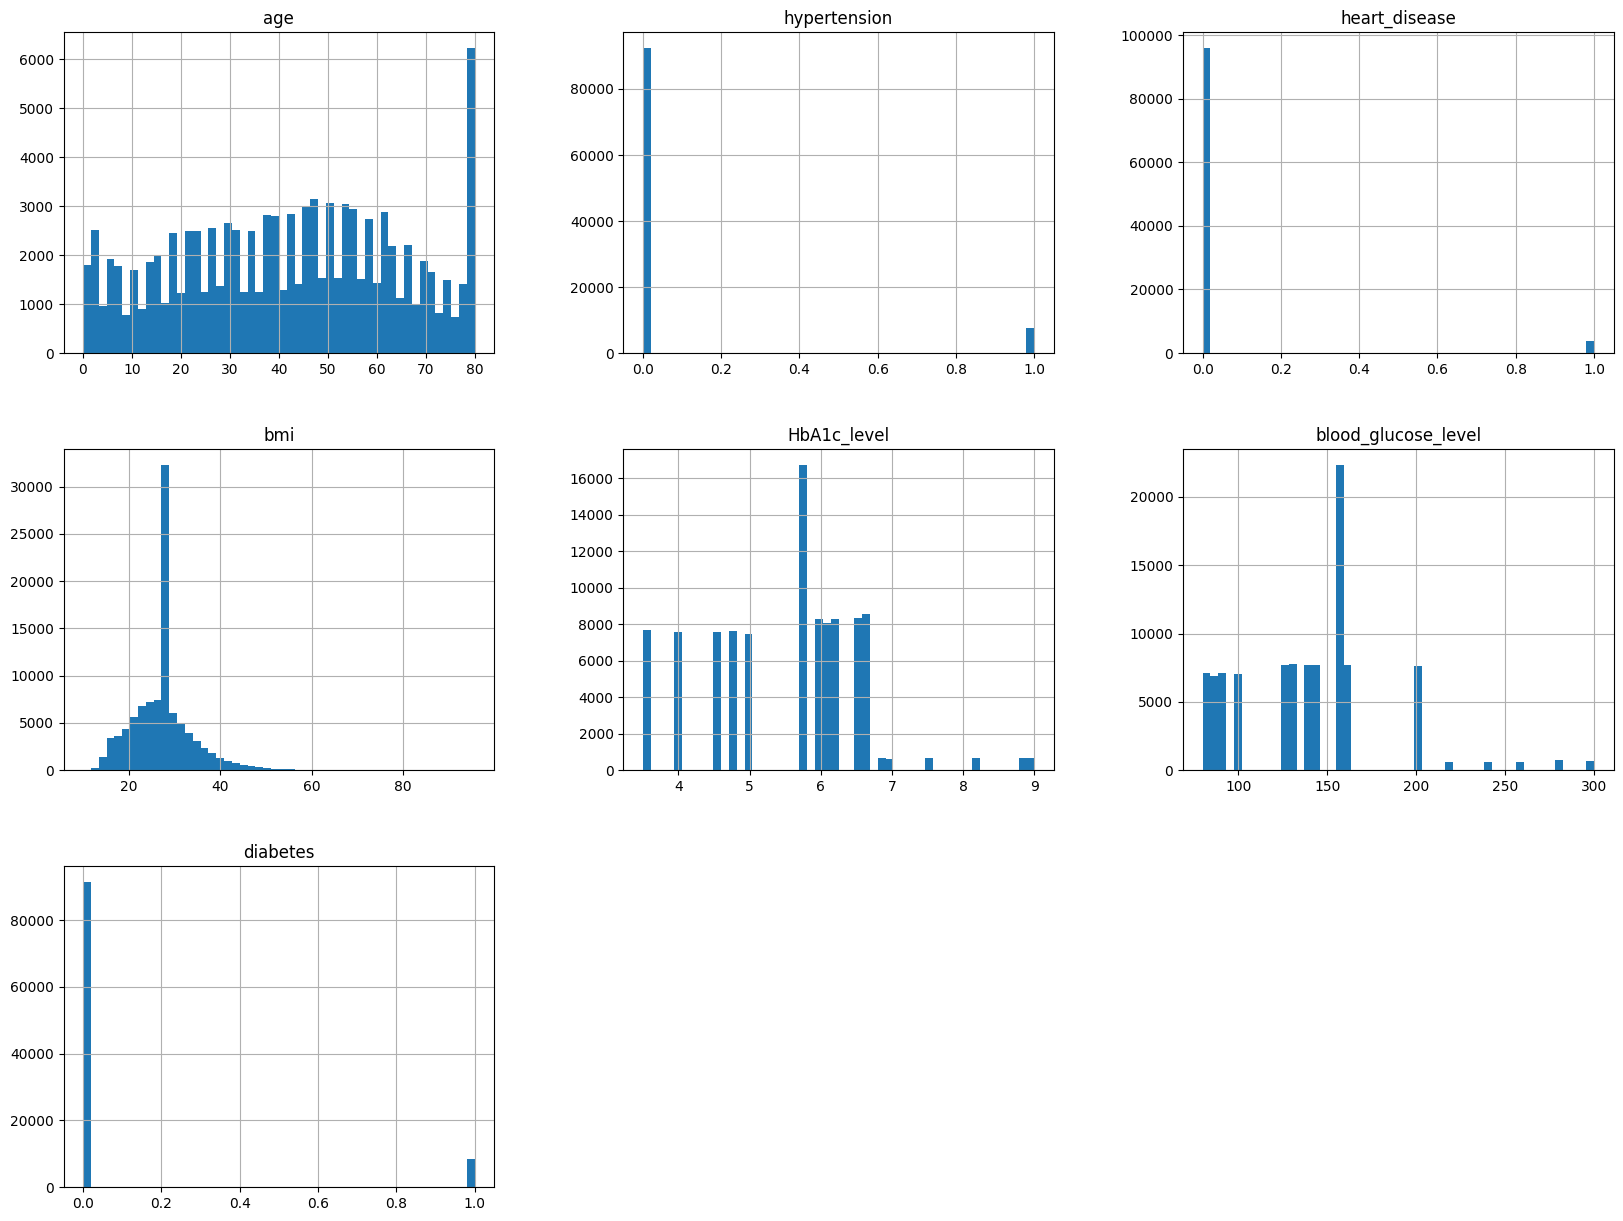

In [55]:
df.hist(bins=50, figsize=(20,15))
plt.show()

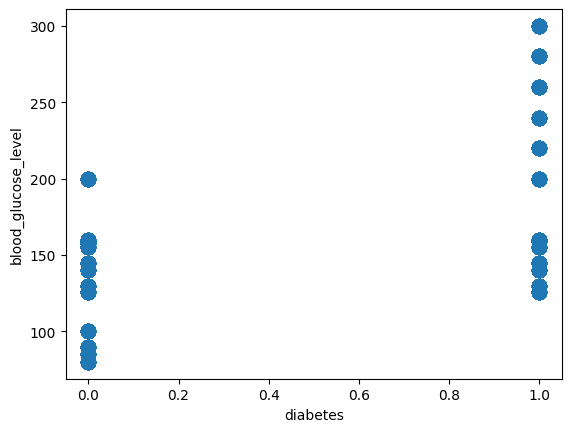

In [58]:
df.plot(kind = 'scatter', x = 'diabetes', y = 'blood_glucose_level', s = 100, alpha = 0.08)
plt.show()

In [64]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Predictions
Y_pred = model.predict(X_test)

# Probability of positive class
Y_prob = model.predict_proba(X_test)[:, 1]

# Evaluation metrics
print("Accuracy:", accuracy_score(Y_test, Y_pred))
print("Precision:", precision_score(Y_test, Y_pred))
print("Recall:", recall_score(Y_test, Y_pred))
print("F1 Score:", f1_score(Y_test, Y_pred))
print("ROC-AUC:", roc_auc_score(Y_test, Y_prob))

Accuracy: 0.95835
Precision: 0.8648874061718098
Recall: 0.6071428571428571
F1 Score: 0.7134502923976608
ROC-AUC: 0.9593722841687105


In [70]:
from sklearn.metrics import confusion_matrix


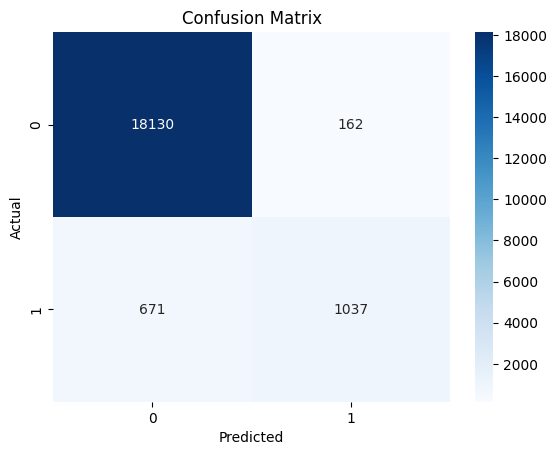

In [71]:
cm = confusion_matrix(Y_test, Y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
# Metrics
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix



In [73]:
# Metrics
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
accuracy_score(Y_test,model.predict(X_test))
classification_report(Y_test,model.predict(X_test))
confusion_matrix(Y_test,model.predict(X_test))
print("accuracy_score:",accuracy_score(Y_test,model.predict(X_test)))
print("classification_report:",classification_report(Y_test,model.predict(X_test)))
print("confusion_matrix:",confusion_matrix(Y_test,model.predict(X_test)))

accuracy_score: 0.95835
classification_report:               precision    recall  f1-score   support

           0       0.96      0.99      0.98     18292
           1       0.86      0.61      0.71      1708

    accuracy                           0.96     20000
   macro avg       0.91      0.80      0.85     20000
weighted avg       0.96      0.96      0.95     20000

confusion_matrix: [[18130   162]
 [  671  1037]]


In [74]:
# Creating dummy data for a new person

dummy_data = pd.DataFrame({
    'gender': ['Male'],
    'age': [55],
    'hypertension': [1],
    'heart_disease': [0],
    'smoking_history': ['former'],
    'bmi': [28.5],
    'HbA1c_level': [6.2],
    'blood_glucose_level': [150]
})

In [76]:
# Convert categorical variables in the same way as training data
dummy_data = pd.get_dummies(dummy_data, drop_first=True)
dummy_data = dummy_data.reindex(columns=X_encoded.columns, fill_value=0)
# Prediction
prediction = model.predict(dummy_data)
print("Prediction:", prediction[0])

if prediction[0] == 1:
    print("The person is predicted to have diabetes.")
else:
    print("The person is predicted not to have diabetes.")

Prediction: 0
The person is predicted not to have diabetes.
